<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/develop/SENSIBILIDADE_HIPERPARAMETRO_RNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
###################################################################
##################################################################
#Instituição: SENAI - CIMATEC
#Curso: Ciência de Dados e Inteligência Artificial (CDIA)
#Disciplina: Inteligência Artificial II
#Autor: Carlos Fernando Arraz | Data: Março, 2024
#UA03 - Roteiro de Prática Guiada 02: sensibilidade dos hiperparâmetros nas RNAs
###################################################################
###################################################################

---

INSTRUÇÕES GERAIS:

---



1 - Realize uma cópia deste arquivo em seu repositório pessoal para iniciar a prática (usar o e-mail institucional para isso);

2 - Reveja o conteúdo teórico e os exemplos práticos vistos até agora na graduação para pontecializar o aprendizado;

3 -Leia a teoria e acompanhe o script python linha a linha e seus comentários (execute as células com **shift + ENTER** ou botão play à esquerda de cada comando/bloco de código), estudando as estruturas, as partes do algoritmo e a lógica proposta;

4 - Execute, modifique, teste e experimente o conteúdo ao máximo para internalizar o conhecimento; e

5- Compare os resultados com bibliotecas de machine learning consagradas no desenvolvimento de soluções em AI.

#Este roteiro tem como objetivo mostrar uma introdução a uma rede neural artificial para reconhecimento de imagens, sendo, portanto, um pouco mais complexa do que vimos até agora, e, tudo isso, através de um script em python🐍.

Um exemplo simples de visão computacional (computer vision)

## Iniciando o código



In [ ]:
#Impotar as bibliotes, neste caso o tensorflow
import tensorflow as tf

print(tf.__version__)

2.17.0


O [conjunto de dados Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) é uma coleção de imagens de roupas em tons de cinza de 28x28 pixels. Cada imagem está associada a um rótulo conforme mostrado nesta tabela ?

| Label | Description |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Este dataset pode ser importado diretamente da biblioteca nativa no Keras [tf.keras.datasets](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) conforme código a seguir:

In [ ]:
# Carregar o Fashion MNIST dataset
fmnist = tf.keras.datasets.fashion_mnist


Chamar `load_data()` neste objeto fornecerá duas tuplas com duas listas cada. Esses serão os valores de treinamento e teste das imagens que contêm as peças de roupa e suas etiquetas.

In [ ]:
#Carregar o training and test split do dataset Fashion MNIST
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Testando uma imagem no dataset:

como são esses valores? Vamos imprimir uma imagem de treinamento (tanto como uma imagem quanto como um array numpy) e um rótulo de treinamento para ver. Experimente diferentes índices no array. Por exemplo, dê uma olhada também no índice `42`. Essa é uma inicialização diferente daquela no índice `0`.


LABEL: 1

IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   0   0   0   0   0  97  84  97 110 108  87  97   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  19 255 199 183 142 161 200 213  32   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  72 174 173 158 131 132 176 176  70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 142 180 163 120 180 126 139 168 122   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 156 180 162 171 170 183 163 169 144   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 159 177 163 174 166 173 170 163 148   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 160 182 160 168 175 167 157 168 139   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 143 185 161 171 184 176 160 175 131   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 143 188 

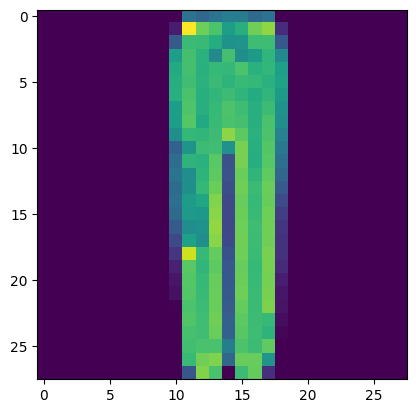

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Voce pode escolher algo entre 0 to 59999 AQUI
index = 1000

# Ajuste numero de caracteres por linha
np.set_printoptions(linewidth=320)

# Imprimir imagem e rótulo
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualizar a imagem
plt.imshow(training_images[index])

Você notará que todos os valores do número estão entre 0 e 255. Se você estiver treinando uma rede neural, especialmente no processamento de imagens, por vários motivos, ela geralmente aprenderá melhor se você dimensionar todos os valores entre 0 e 1. É um processo chamado _normalização_ e, felizmente, em Python, é fácil normalizar um array sem loop. Você faz assim:

In [ ]:
# Normalize o valor do pixel das imagens no treino e teste
training_images  = training_images / 255.0
test_images = test_images / 255.0

Agora você deve estar se perguntando por que o conjunto de dados é dividido em dois: treinamento e teste? Lembra que falamos sobre isso na introdução? A ideia é ter 1 conjunto de dados para treinamento e depois outro conjunto de dados que o modelo ainda não viu. Isso será usado para avaliar quão bom seria na classificação de valores.

Vamos agora projetar o modelo. Existem alguns conceitos novos aqui. Mas não se preocupe, você vai pegar o jeito deles.

In [ ]:
# Construir um modelo simples de classificação
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

A próxima coisa a fazer, agora que o modelo está definido, é realmente construí-lo. Você faz isso compilando-o com um otimizador e uma função de perda como antes - e então você o treina chamando `model.fit()` pedindo para ajustar seus dados de treinamento aos seus rótulos de treinamento. Ele descobrirá a relação entre os dados de treinamento e seus rótulos reais; portanto, no futuro, se você tiver entradas que se pareçam com os dados de treinamento, ele poderá prever qual é o rótulo dessa entrada.

In [ ]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7807 - loss: 0.6359
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8608 - loss: 0.3907
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8776 - loss: 0.3398
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8839 - loss: 0.3195
Epoch 5/5
 171/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8864 - loss: 0.3009

Depois de concluir o treinamento - você deverá ver um valor de precisão no final da época final. Pode ser algo como `0,9098`. Isso indica que sua rede neural tem cerca de 91% de precisão na classificação dos dados de treinamento. Ou seja, descobriu uma correspondência de padrões entre a imagem e os rótulos que funcionou 91% das vezes. Não é ótimo, mas não é ruim, considerando que foi treinado apenas por 5 épocas e feito rapidamente.

Mas como isso funcionaria com dados invisíveis? É por isso que temos as imagens e rótulos de teste. Podemos chamar [`model.evaluate()`](https://keras.io/api/models/model_training_apis/#evaluate-method) com este conjunto de dados de teste como entradas e ele reportará a perda e a precisão do modelo . Vamos tentar:

In [ ]:
# Avaliar o modelo para dados ainda não vistos
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.3445 - accuracy: 0.8753


[0.34450146555900574, 0.8752999901771545]

Você pode esperar que a precisão aqui seja de cerca de `0,88`, o que significa que foi 88% preciso em todo o conjunto de testes. Como esperado, provavelmente não funcionaria tão bem com dados *invisíveis* quanto com os dados nos quais foi treinado! Ao longo deste curso, você verá maneiras de melhorar isso.

Referências:

[1] Código adaptado. DeepLearning.ai. Conteúdo online modificado. GitHub, https://github.com/https-deeplearning-ai/tensorflow-1-public/blob/main/C1/W2/ungraded_labs/C1_W2_Lab_1_beyond_hello_world.ipynb . Licença Apache 2.0. Acesso em: 19 fev. 2024.

[2] FACELI, Katti; et al. Inteligência artificial: uma abordagem de aprendizado de máquina. Rio de Janeiro:  GEN, 2021. E-book. ISBN 9788521637509.

[3] -GÉRON, Aurélien. Mãos à obra - aprendizado de máquina com scikit-learn, Keras & TensorFlow: conceitos, ferramentas e técnicas para a construção de sistemas inteligentes. Rio de Janeiro: Alta Books, 2021. E-book. ISBN 9786555208146.

[4] NETTO, Amilcar; MACIEL, Francisco. Python para data science e machine learning descomplicado. Rio de Janeiro: Alta Books, 2021. E-book. ISBN 9786555203172.